# Prévision des prix de l'immobilier avec Python

La prévision des prix immobiliers consiste à estimer ou à prévoir les prix futurs de biens immobiliers, tels que des maisons, des appartements ou des immeubles commerciaux. L'objectif est de fournir des prix immobiliers précis aux acheteurs, vendeurs, investisseurs et professionnels de l'immobilier afin qu'ils puissent prendre des décisions éclairées lors de leurs transactions immobilières. Si vous souhaitez apprendre à prédire les prix de l'immobilier, je vous explique comment prédire les prix de l'immobilier grâce au Machine Learning en Python.


# Prévision des prix de l'immobilier : processus à suivre
Vous trouverez ci-dessous le processus que nous pouvons suivre pour prédire les prix de l'immobilier afin d'aider les particuliers et les entreprises à prendre des décisions éclairées sur le marché immobilier :


1. Recueillez des données pertinentes à partir de diverses sources, notamment des bases de données immobilières, des registres gouvernementaux, des listes en ligne et d’autres sources publiques ou privées.

2. Nettoyez et préparez les données collectées en gérant les valeurs manquantes, en supprimant les valeurs aberrantes et en convertissant les variables catégorielles en représentations numériques.

3. Créez de nouvelles fonctionnalités ou transformez celles existantes pour capturer des informations importantes qui peuvent influencer les prix de l'immobilier.

4. Explorez et visualisez les données pour mieux comprendre leur distribution, leurs corrélations et leurs modèles.

5. Choisissez des algorithmes d’apprentissage automatique ou des modèles prédictifs appropriés pour la tâche.

6. Entraînez le modèle sélectionné sur les données d'entraînement, en optimisant ses paramètres pour faire des prédictions précises.

Pour la prévision des prix de l'immobilier, nous avons besoin de données historiques présentant diverses caractéristiques susceptibles d'influencer les prix de l'immobilier. J'ai trouvé un ensemble de données idéal pour cette tâche. Vous pouvez le télécharger ici .
https://statso.io/2023/12/11/real-estate-prediction-case-study/

Maintenant, commençons la tâche de prédiction des prix de l'immobilier en important les bibliothèques Python nécessaires et l' ensemble de données :

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#from google.colab import files
# Permettre à l'utilisateur de télécharger un fichier
# uploaded = files.upload()

In [4]:
#Charger l'ensemble des données
real_estate_data = pd.read_csv('C:\\Users\\moussa.bakayoko\\Desktop\\Projet perso\\Prédiction immobilière\\Real_Estate.csv')

#Affiche les premieres lignes de l'ensemble de données et les informations sur l'ensemble des données
real_estate_data_head = real_estate_data.head()
data_info = real_estate_data.info()

print(real_estate_data_head)
print(data_info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Transaction date                     414 non-null    object 
 1   House age                            414 non-null    float64
 2   Distance to the nearest MRT station  414 non-null    float64
 3   Number of convenience stores         414 non-null    int64  
 4   Latitude                             414 non-null    float64
 5   Longitude                            414 non-null    float64
 6   House price of unit area             414 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 22.8+ KB
             Transaction date  House age  Distance to the nearest MRT station  \
0  2012-09-02 16:42:30.519336       13.3                            4082.0150   
1  2012-09-04 22:52:29.919544       35.5                             274.0144

L'ensemble de données contient sept colonnes. Voici un bref aperçu de chacune d'elles :


1. Date de transaction : La date de la transaction immobilière.
2. Âge de la maison : Âge de la maison en années.
3. Distance jusqu'à la station MRT la plus proche : Distance jusqu'à la station Mass Rapid Transit la plus proche en mètres.

4. Nombre de commerces de proximité : Nombre de commerces de proximité à proximité.
5. Latitude : Latitude de l'emplacement de la propriété.
6. Longitude : Longitude de l'emplacement de la propriété.
7. Prix de la maison par unité de surface : Prix de la maison par unité de surface.

Voyons maintenant si les données contiennent des valeurs nulles ou non :

In [5]:
print(real_estate_data.isnull().sum())

Transaction date                       0
House age                              0
Distance to the nearest MRT station    0
Number of convenience stores           0
Latitude                               0
Longitude                              0
House price of unit area               0
dtype: int64


L'ensemble de données ne contient aucune valeur nulle. Examinons maintenant les statistiques descriptives de l'ensemble de données :

In [6]:
#Statistiques descriptives de l'ensemble de données
descriptive_stats = real_estate_data.describe()
print(descriptive_stats)

        House age  Distance to the nearest MRT station  \
count  414.000000                           414.000000   
mean    18.405072                          1064.468233   
std     11.757670                          1196.749385   
min      0.000000                            23.382840   
25%      9.900000                           289.324800   
50%     16.450000                           506.114400   
75%     30.375000                          1454.279000   
max     42.700000                          6306.153000   

       Number of convenience stores    Latitude   Longitude  \
count                    414.000000  414.000000  414.000000   
mean                       4.265700   24.973605  121.520268   
std                        2.880498    0.024178    0.026989   
min                        0.000000   24.932075  121.473888   
25%                        2.000000   24.952422  121.496866   
50%                        5.000000   24.974353  121.520912   
75%                        6.750000 

Maintenant, regardons les histogrammes de toutes les caractéristiques numériques :

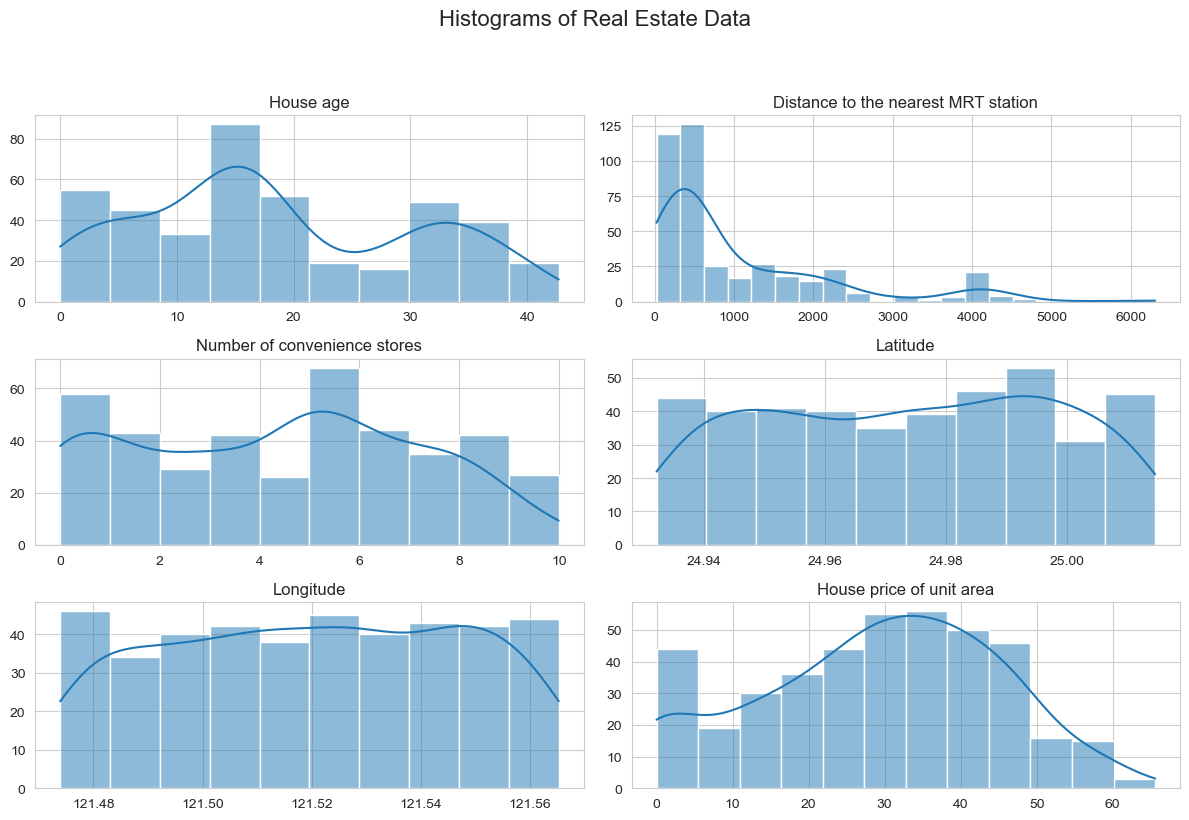

In [7]:
#definir le style esthétique des tracés
sns.set_style('whitegrid')

# creer des histogramme pour les colonnes numeriques
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
fig.suptitle('Histograms of Real Estate Data', fontsize=16)

cols = ['House age', 'Distance to the nearest MRT station', 'Number of convenience stores',
        'Latitude', 'Longitude', 'House price of unit area']


for i, col in enumerate(cols):
  sns.histplot(real_estate_data[col], kde=True, ax=axes[i//2, i%2])
  axes[i//2, i%2].set_title(col)
  axes[i//2, i%2].set_xlabel('')
  axes[i//2, i%2].set_ylabel('')

plt.tight_layout(rect=[0, 0.3, 1, 0.95])
plt.show()

Les histogrammes donnent un aperçu de la distribution de chaque variable :


1. Âge de la maison : Cela montre une distribution relativement uniforme avec une légère augmentation du nombre de propriétés plus récentes (âge inférieur).

2. Distance jusqu'à la station de MRT la plus proche : La plupart des propriétés sont situées à proximité d'une station de MRT, comme l'indique la fréquence élevée des distances plus faibles. On observe une longue traîne vers les distances plus élevées, suggérant que certaines propriétés sont assez éloignées des stations de MRT.

3. Nombre de dépanneurs : affiche une large gamme, avec des pics notables à des nombres spécifiques, comme 0, 5 et 10. Il suggère certaines configurations courantes en termes de disponibilité des dépanneurs.

4. Latitude et longitude : les deux montrent des distributions relativement concentrées, indiquant que les propriétés sont situées dans une zone géographiquement limitée.
5. Prix ​​des maisons par unité de surface : affiche une distribution asymétrique à droite, avec une concentration de propriétés dans la fourchette de prix inférieure et moins de propriétés à mesure que les prix augmentent.

Ensuite, je créerai des nuages ​​de points pour explorer les relations entre ces variables et le prix de l'immobilier. Cela nous aidera à comprendre quels facteurs pourraient influencer le plus significativement les prix de l'immobilier :

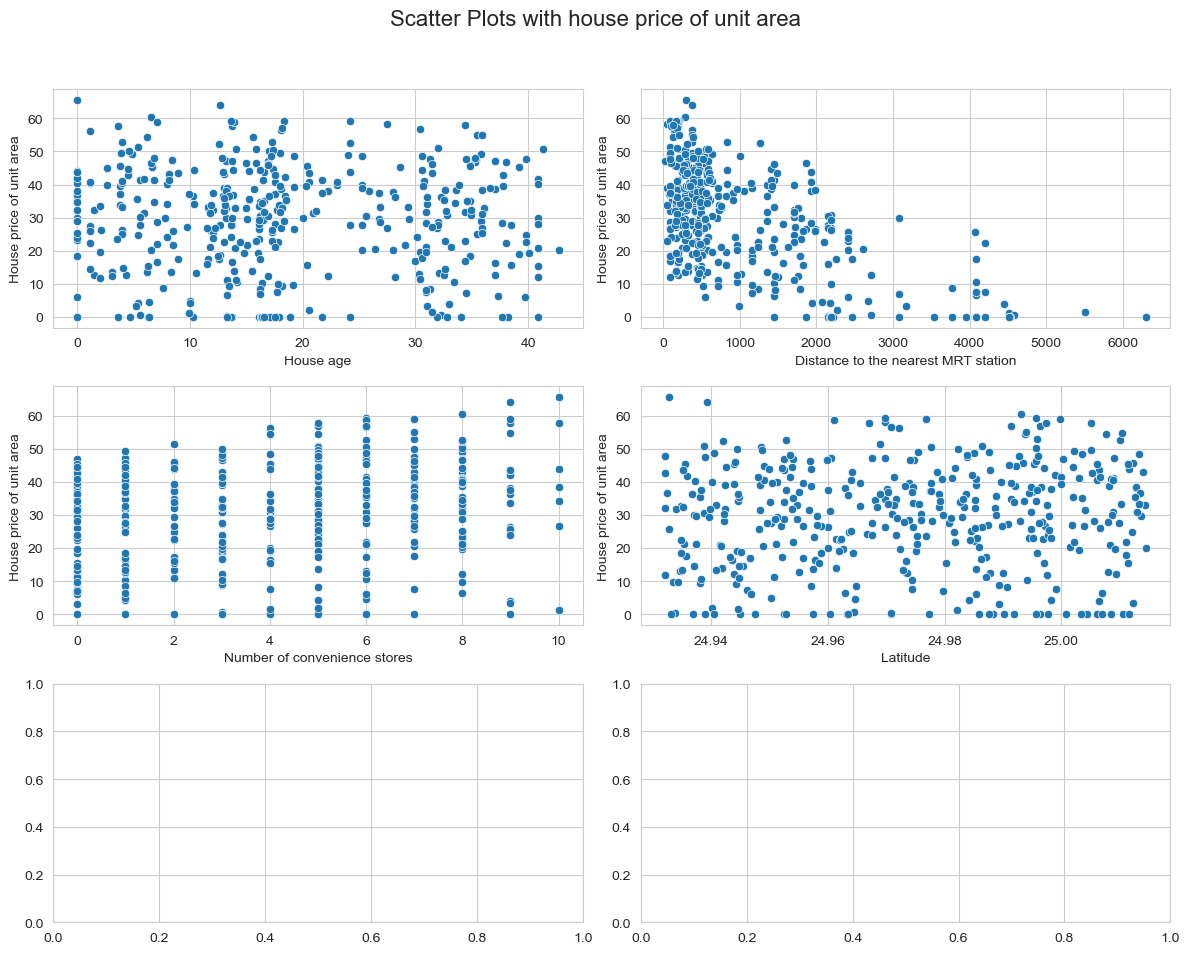

In [8]:
# Nuages de points pour observer la relation avec le prix de l'immobilier
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
fig.suptitle('Scatter Plots with house price of unit area', fontsize=16)

#Nuage de points pour chaque variable par rapport au prix de la maison
sns.scatterplot(data=real_estate_data, x='House age', y='House price of unit area', ax=axes[0, 0])
sns.scatterplot(data=real_estate_data, x='Distance to the nearest MRT station', y='House price of unit area', ax=axes[0, 1])
sns.scatterplot(data=real_estate_data, x='Number of convenience stores', y='House price of unit area', ax=axes[1, 0])
sns.scatterplot(data=real_estate_data, x='Latitude', y='House price of unit area', ax=axes[1, 1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Les diagrammes de dispersion ont révélé des relations intéressantes entre divers facteurs et les prix des logements :

1. Âge et prix des maisons : Il ne semble pas y avoir de relation linéaire forte entre l'âge et le prix des maisons. Cependant, il semble que les maisons très récentes et très anciennes puissent avoir des prix plus élevés.

2. Distance à la station de MRT la plus proche vs. Prix de l'immobilier : Une tendance claire montre que plus la distance à la station de MRT la plus proche augmente, plus le prix de l'immobilier tend à diminuer. Cela suggère une forte corrélation négative entre ces deux variables.

3. Nombre de commerces de proximité et prix de l'immobilier : Il semble y avoir une corrélation positive entre le nombre de commerces de proximité et le prix de l'immobilier. Les maisons situées à proximité de nombreux commerces de proximité ont tendance à afficher des prix plus élevés.

4. Latitude vs. Prix de l'immobilier : Bien qu'il n'existe pas de relation linéaire forte, il semble exister une tendance selon laquelle certaines  latitudes correspondent à des prix de l'immobilier plus ou moins élevés. Cela pourrait indiquer que certains quartiers sont plus recherchés.

Enfin, il serait utile d’effectuer une analyse de corrélation pour quantifier les relations entre ces variables, en particulier la manière dont chacune d’entre elles est corrélée au prix de la maison :

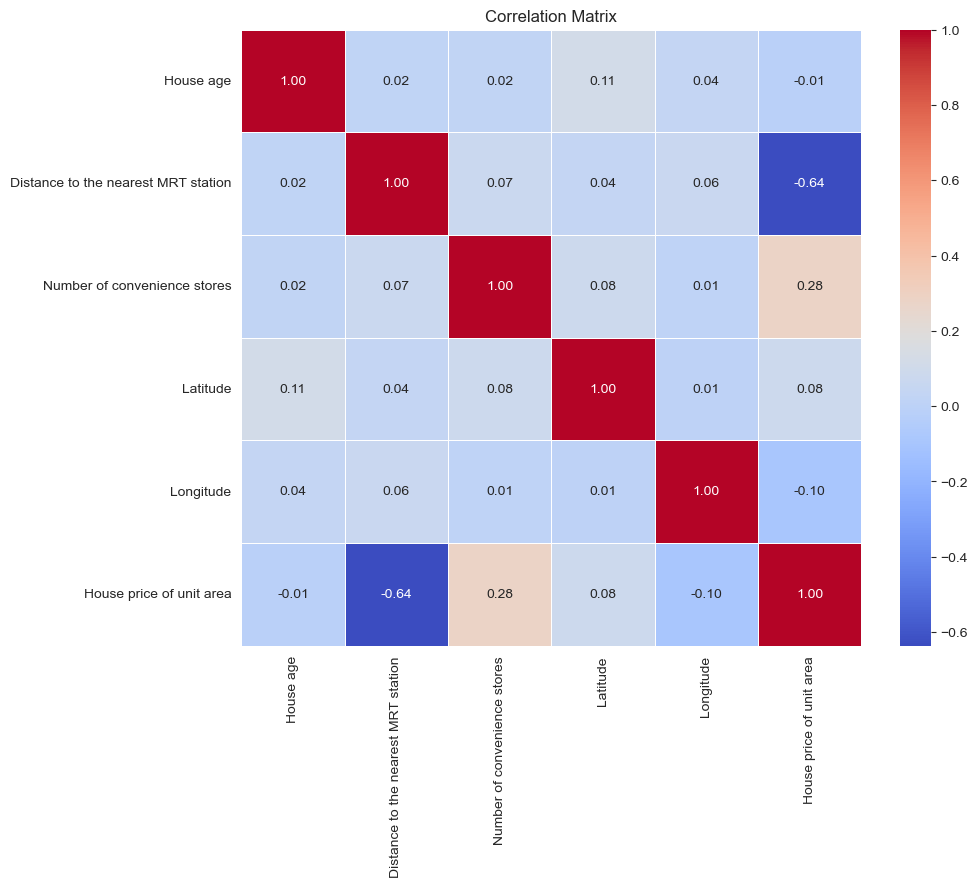

                                     House age  \
House age                             1.000000   
Distance to the nearest MRT station   0.021596   
Number of convenience stores          0.021973   
Latitude                              0.114345   
Longitude                             0.036449   
House price of unit area             -0.012284   

                                     Distance to the nearest MRT station  \
House age                                                       0.021596   
Distance to the nearest MRT station                             1.000000   
Number of convenience stores                                    0.069015   
Latitude                                                        0.038954   
Longitude                                                       0.064229   
House price of unit area                                       -0.636579   

                                     Number of convenience stores  Latitude  \
House age                            

In [9]:
#Matrice de correlation
correlation_matrix = real_estate_data.drop('Transaction date', axis=1).corr()

# Tracé de la matrice de correlation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

print(correlation_matrix)

La matrice de corrélation fournit des informations quantifiées sur la manière dont chaque variable est liée aux autres, en particulier en ce qui concerne le prix de l'immobilier :

1. Âge de la maison : cela montre une très faible corrélation négative avec le prix de la maison (-0,012), ce qui implique que l'âge n'est pas un bon prédicteur du prix dans cet ensemble de données.
2. Distance de la station de MRT la plus proche : forte corrélation négative avec le prix de l'immobilier (-0,637). Cela indique que les propriétés proches des stations de MRT ont tendance à être plus chères, ce qui constitue un facteur important dans l'évaluation immobilière.
3. Nombre de commerces de proximité : Corrélation positive modérée avec le prix de l'immobilier (0,281). La présence de commerces de proximité semble avoir un impact positif sur le prix de l'immobilier.
4. Latitude et longitude : elles présentent toutes deux une faible corrélation avec les prix de l'immobilier. La latitude présente une légère corrélation positive (0,081), tandis que la longitude présente une légère corrélation négative (-0,099).

Globalement, les facteurs les plus importants influençant le prix des logements dans cet ensemble de données semblent être la proximité des stations de MRT et le nombre de commerces de proximité. La situation géographique (latitude et longitude) et l'âge du logement semblent avoir moins d'impact sur le prix.


Construisons maintenant un modèle de régression pour prédire les prix de l'immobilier en utilisant l' algorithme de régression linéaire :

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# selection des fonctionnalités et de la variable cible
features = ['Distance to the nearest MRT station', 'Number of convenience stores', 'Latitude', 'Longitude']
target = 'House price of unit area'

X = real_estate_data[features]
y = real_estate_data[target]

# division de l'ensemble de données en ensemble d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# initialisation du model
model = LinearRegression()

# entrainement du model
model.fit(X_train, y_train)

LinearRegression()

Maintenant, visualisons les valeurs réelles par rapport aux valeurs prédites pour évaluer les performances de notre modèle :

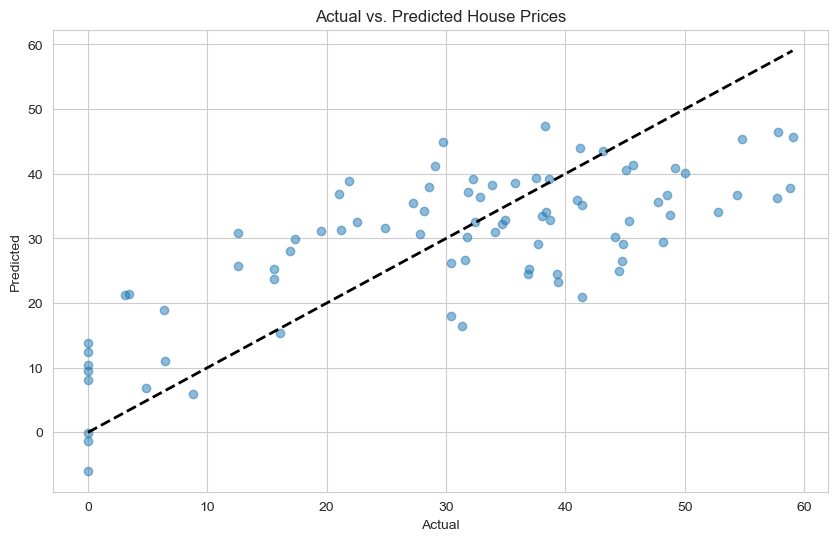

In [11]:
y_pred_lr = model.predict(X_test)

# Visualization: valeurs réelles et valeurs prédites
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted House Prices')
plt.show()

La ligne pointillée diagonale représente l'égalité entre les valeurs réelles et prédites. Les points proches de cette ligne indiquent des prédictions exactes. Le graphique montre :

- De nombreux points sont proches de la ligne diagonale, ce qui suggère que le modèle fait des prédictions raisonnablement précises pour une partie importante de l’ensemble de tests.

- Certains points sont plus éloignés de la ligne, indiquant des zones où les prédictions du modèle s'écartent plus significativement des valeurs réelles.
Voilà donc comment nous pouvons prédire les prix de l’immobilier avec l’apprentissage automatique en utilisant Python.

# Résumé
La prévision des prix immobiliers consiste à estimer ou à prévoir les prix futurs de biens immobiliers, tels que des maisons, des appartements ou des immeubles commerciaux. L'objectif est de fournir des prix immobiliers précis aux acheteurs, vendeurs, investisseurs et professionnels de l'immobilier afin qu'ils puissent prendre des décisions éclairées lors de leurs transactions immobilières.